In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

# Define imbalance ratios and file paths
ratios = [1, 2, 5, 10, 15, 20, 30, 40, 45, 50]
metrics = []
cv_box = {'LIME': [], 'SHAP': []}     # For boxplots of CV
csi_box = {'LIME': []}               # distributions of feature CSIs
vsi_box = {'LIME': []}               # distributions of pairwise Jaccards (internal VSI)

for ratio in ratios:
    # Load the 100-run explanation CSVs for this ratio
    lime_file = f'results/iterations/lime_iterations_{ratio}.csv'
    shap_file = f'results/iterations/shap_iterations_{ratio}.csv'
    lime_df = pd.read_csv(lime_file)
    shap_df = pd.read_csv(shap_file)
    
    # Ensure features (columns) are aligned
    features = list(lime_df.columns)
    P = len(features)
    n_runs = len(lime_df)

    # ==== Compute CV for each feature, then aggregate ====
    # CoV = std/mean for each feature
    lime_std = lime_df.std(axis=0)
    lime_mean = lime_df.mean(axis=0)
    # avoid division by zero: add small eps if needed
    eps = 1e-8
    lime_cv = (lime_std / (lime_mean.abs() + eps)).replace([np.inf, -np.inf], np.nan).fillna(0)
    shap_std = shap_df.std(axis=0)
    shap_mean = shap_df.mean(axis=0)
    shap_cv = (shap_std / (shap_mean.abs() + eps)).replace([np.inf, -np.inf], np.nan).fillna(0)
    # median CV across features as summary
    cv_lime = np.nanmedian(lime_cv.values)
    cv_shap = np.nanmedian(shap_cv.values)
    cv_box['LIME'].append(lime_cv.values)
    cv_box['SHAP'].append(shap_cv.values)
    
    # ==== Compute SRA for K=1..5 ====
    # For each run, get ranks of features (1=highest importance)
    def get_rank_matrix(df):
        # df: runs x features
        n_runs, n_features = df.shape
        rank_mat = np.zeros((n_runs, n_features), dtype=int)
        for i in range(n_runs):
            vals = df.iloc[i].values
            # argsort descending: index of features sorted by decreasing importance
            sorted_idx = np.argsort(-vals)
            # Assign ranks: top gets rank 1
            ranks = np.empty(n_features, dtype=int)
            ranks[sorted_idx] = np.arange(1, n_features+1)
            rank_mat[i] = ranks
        return rank_mat

    lime_ranks = get_rank_matrix(lime_df)
    shap_ranks = get_rank_matrix(shap_df)

    sra_vals_lime = {}
    sra_vals_shap = {}
    for K in range(1, 6):
        # Define set S of features appearing in top-K of any run
        S_lime = set(np.where((lime_ranks <= K))[1])
        S_shap = set(np.where((shap_ranks <= K))[1])
        # Compute pooled variance of ranks in S
        def compute_sra(rank_mat, S):
            if len(S) == 0:
                return np.nan
            S = list(S)
            ranks_S = rank_mat[:, S]          # shape (n_runs, len(S))
            avg_rank = ranks_S.mean(axis=0)   # average rank per feature in S
            # sum of squared devs
            dev2 = ((ranks_S - avg_rank)**2).sum()
            # pooled variance (per-depth)
            return np.sqrt(dev2 / (rank_mat.shape[0] * len(S)))
        sra_vals_lime[K] = compute_sra(lime_ranks, S_lime)
        sra_vals_shap[K] = compute_sra(shap_ranks, S_shap)

    # ==== Compute CSI and VSI for LIME only ====
    # CSI: 1 - (std / max_std) for each feature
    max_std = lime_std.max() + eps
    csi_values = 1.0 - (lime_std / max_std)
    csi_values = np.clip(csi_values, 0, 1)
    # Record feature-wise CSI for boxplot later
    csi_box['LIME'].append(csi_values.values)

    # VSI (internal): compute Jaccard for top-5 feature sets between runs
    topK = 5
    # get sets of top-K features for each run
    sets = []
    for i in range(n_runs):
        # indices of topK features by absolute importance (descending)
        top_idx = np.argsort(-lime_df.iloc[i].values)[:topK]
        sets.append(set(top_idx))
    # compute all pairwise Jaccard similarities
    import numpy as np
    import itertools
    
    rng = np.random.default_rng(42)
    pair_gen = itertools.combinations(range(n_runs), 2)
    subset = list(itertools.islice(pair_gen, 100000))  # safe slice
    sample_pairs = rng.choice(subset, size=10000, replace=False)
    jsims = []
    for (a, b) in sample_pairs:
        s1, s2 = sets[a], sets[b]
        sim = len(s1 & s2) / len(s1 | s2) if s1 or s2 else 1.0
        jsims.append(sim)
    vsi_box['LIME'].append(jsims)
    # Also record average VSI (for metrics CSV, though boxplot uses jsims)
    avg_vsi = np.mean(jsims) * 100  # as percentage

    # Aggregate CSI (e.g. mean) for reporting
    avg_csi = np.mean(csi_values)

    # Save metrics for this ratio
    metrics.append({
        'ratio': ratio, 'method': 'LIME',
        'SRA1': sra_vals_lime[1], 'SRA2': sra_vals_lime[2],
        'SRA3': sra_vals_lime[3], 'SRA4': sra_vals_lime[4],
        'SRA5': sra_vals_lime[5], 'CV_med': cv_lime,
        'CSI': avg_csi, 'VSI': avg_vsi
    })
    metrics.append({
        'ratio': ratio, 'method': 'SHAP',
        'SRA1': sra_vals_shap[1], 'SRA2': sra_vals_shap[2],
        'SRA3': sra_vals_shap[3], 'SRA4': sra_vals_shap[4],
        'SRA5': sra_vals_shap[5], 'CV_med': cv_shap,
        'CSI': None,    # not applicable for SHAP
        'VSI': None     # not applicable
    })

# Save all metrics to CSV
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv('metrics/explanation_stability_metrics.csv', index=False)

# ==== Generate plots ====

# 1. Line plots of average SRA vs imbalance for K=1..5 (separate for LIME/SHAP)
fig, axs = plt.subplots(1, 2, figsize=(12,5))
for (method, ax) in zip(['LIME','SHAP'], axs):
    for K in range(1,6):
        y = [row[f'SRA{K}'] for _, row in metrics_df[metrics_df.method==method].iterrows()]
        ax.plot(ratios, y, marker='o', label=f'K={K}')
    ax.set_xscale('log')
    ax.set_xlabel('Imbalance Ratio (%)')
    ax.set_ylabel('SRA (pooled std dev of ranks)')
    ax.set_title(f'{method} SRA vs Imbalance')
    ax.legend(title='Top-K')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plots/SRA_vs_imbalance.png')
plt.close()

# 2. Boxplots of CV vs imbalance (LIME vs SHAP)
fig, axs = plt.subplots(1, 2, figsize=(12,5))
for i, method in enumerate(['LIME','SHAP']):
    data = cv_box[method]
    axs[i].boxplot(data, positions=range(len(ratios)), showmeans=False)
    axs[i].set_xticks(range(len(ratios)))
    axs[i].set_xticklabels([str(r) for r in ratios], rotation=45)
    axs[i].set_xlabel('Imbalance Ratio (%)')
    axs[i].set_ylabel('Feature CoV')
    axs[i].set_title(f'{method} CV across Features')
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plots/CV_boxplots.png')
plt.close()

# 3. Boxplots of CSI and VSI (internal LIME stability) vs imbalance
# For CSI: use distribution of feature CSIs; for VSI: distribution of all pairwise Jaccards.
fig, axs = plt.subplots(1, 2, figsize=(12,5))
# CSI distribution
data_csi = csi_box['LIME']  # list of arrays of CSI per feature
axs[0].boxplot(data_csi, positions=range(len(ratios)), showmeans=False)
axs[0].set_xticks(range(len(ratios)))
axs[0].set_xticklabels([str(r) for r in ratios], rotation=45)
axs[0].set_xlabel('Imbalance Ratio (%)')
axs[0].set_ylabel('Feature CSI (1 – normalized STD)')
axs[0].set_title('LIME Coefficient Stability Index (CSI)')
axs[0].grid(axis='y', linestyle='--', alpha=0.5)
# VSI distribution (internal): use Jaccard sims
data_vsi = vsi_box['LIME']
axs[1].boxplot(data_vsi, positions=range(len(ratios)), showmeans=False)
axs[1].set_xticks(range(len(ratios)))
axs[1].set_xticklabels([str(r) for r in ratios], rotation=45)
axs[1].set_xlabel('Imbalance Ratio (%)')
axs[1].set_ylabel('Pairwise Jaccard (top-5 features)')
axs[1].set_title('LIME Variable Stability Index (VSI) – Internal')
axs[1].grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plots/CSI_VSI_boxplots.png')
plt.close()

In [15]:
os.makedirs('metrics', exist_ok=True)

Processing SHAP explanations for 1% imbalance
Processing SHAP explanations for 2% imbalance
Processing SHAP explanations for 5% imbalance
Processing SHAP explanations for 10% imbalance
Processing SHAP explanations for 15% imbalance
Processing SHAP explanations for 20% imbalance
Processing SHAP explanations for 30% imbalance
Processing SHAP explanations for 40% imbalance
Processing SHAP explanations for 45% imbalance
Processing SHAP explanations for 50% imbalance


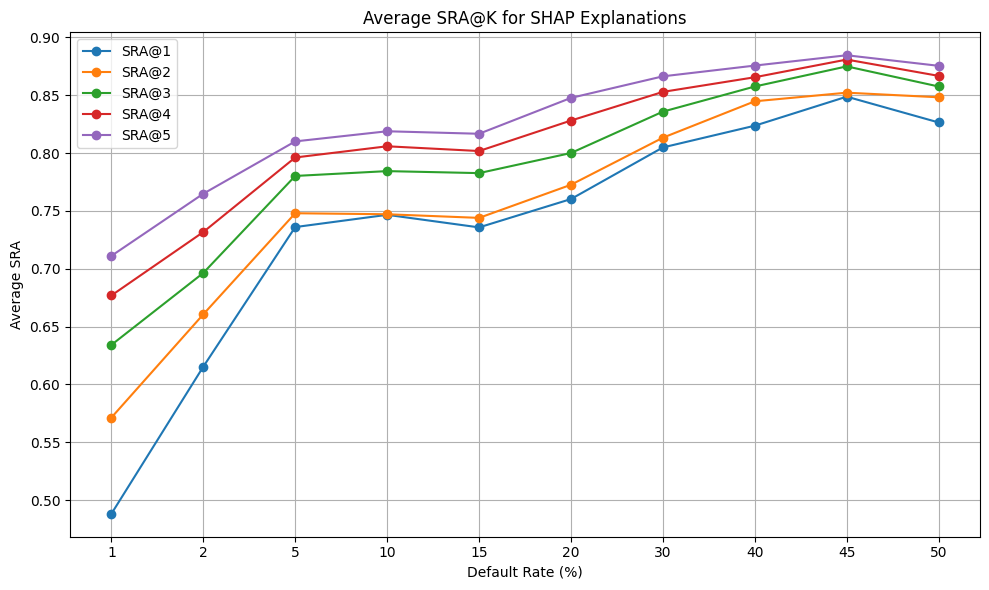

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

# === CONFIGURATION ===
ratios = ["1", "2", "5", "10", "15", "20", "30", "40", "45", "50"]
k_list = [1, 2, 3, 4, 5]
sra_scores = {k: [] for k in k_list}

def compute_sra_at_k(ranked_lists, k):
    """
    ranked_lists: List of ranked feature indices for the same instance over runs
    k: depth of ranking list to evaluate SRA@k
    """
    topk_lists = [tuple(r[:k]) for r in ranked_lists]
    match_matrix = np.zeros((len(topk_lists), len(topk_lists)))
    
    for i in range(len(topk_lists)):
        for j in range(len(topk_lists)):
            match_matrix[i, j] = len(set(topk_lists[i]).intersection(set(topk_lists[j]))) / k
    
    return match_matrix[np.triu_indices(len(topk_lists), k=1)].mean()

# === MAIN LOOP ===
for ratio in ratios:
    print(f"Processing SHAP explanations for {ratio}% imbalance")
    df = pd.read_csv(f"results/iterations/shap_iterations_{ratio}.csv")
    feature_cols = [col for col in df.columns if col not in ['iteration']]
    
    # Group by iteration → list of DataFrames (each run)
    runs = [df[df['iteration'] == i][feature_cols].values for i in range(100)]

    # Transpose to per-instance
    n_instances = runs[0].shape[0]
    
    for k in k_list:
        sra_per_instance = []
        for inst_idx in range(n_instances):
            rankings = [np.argsort(-run[inst_idx]) for run in runs]  # - for descending
            sra = compute_sra_at_k(rankings, k)
            sra_per_instance.append(sra)
        avg_sra = np.mean(sra_per_instance)
        sra_scores[k].append(avg_sra)

# === PLOT ===
plt.figure(figsize=(10, 6))
for k in k_list:
    plt.plot(ratios, sra_scores[k], marker='o', label=f'SRA@{k}')
plt.xlabel("Default Rate (%)")
plt.ylabel("Average SRA")
plt.title("Average SRA@K for SHAP Explanations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Processing LIME explanations for 1% imbalance
Processing LIME explanations for 2% imbalance
Processing LIME explanations for 5% imbalance
Processing LIME explanations for 10% imbalance
Processing LIME explanations for 15% imbalance
Processing LIME explanations for 20% imbalance
Processing LIME explanations for 30% imbalance
Processing LIME explanations for 40% imbalance
Processing LIME explanations for 45% imbalance
Processing LIME explanations for 50% imbalance


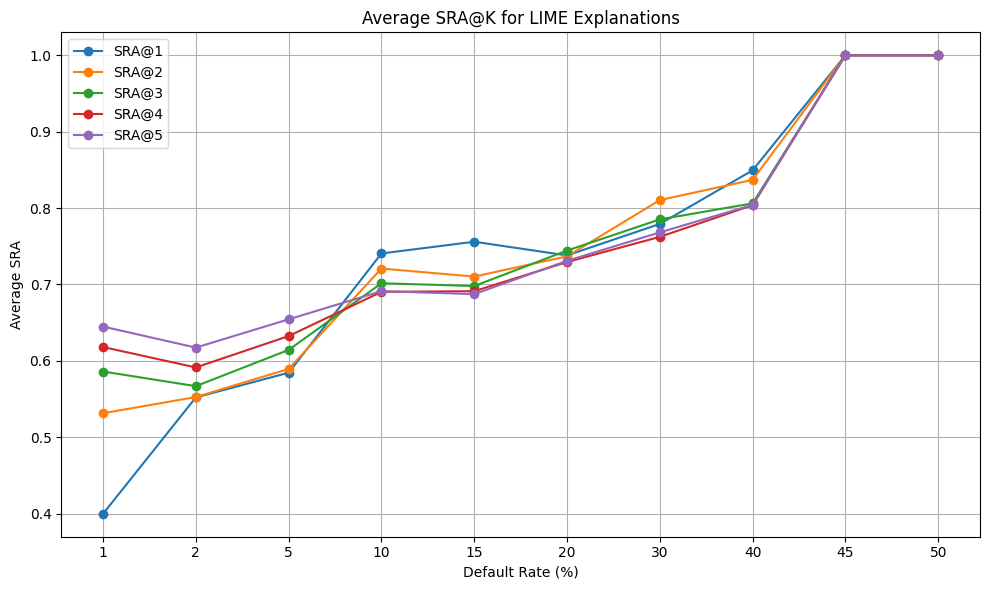

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

# === CONFIGURATION ===
ratios = ["1", "2", "5", "10", "15", "20", "30", "40", "45", "50"]
k_list = [1, 2, 3, 4, 5]
sra_scores_lime = {k: [] for k in k_list}

def compute_sra_at_k(ranked_lists, k):
    topk_lists = [tuple(r[:k]) for r in ranked_lists]
    match_matrix = np.zeros((len(topk_lists), len(topk_lists)))
    
    for i in range(len(topk_lists)):
        for j in range(len(topk_lists)):
            match_matrix[i, j] = len(set(topk_lists[i]).intersection(set(topk_lists[j]))) / k
    
    return match_matrix[np.triu_indices(len(topk_lists), k=1)].mean()

# === MAIN LOOP ===
for ratio in ratios:
    print(f"Processing LIME explanations for {ratio}% imbalance")
    df = pd.read_csv(f"results/iterations/lime_iterations_{ratio}.csv")
    feature_cols = [col for col in df.columns if col not in ['iteration']]
    
    runs = [df[df['iteration'] == i][feature_cols].values for i in range(100)]
    n_instances = runs[0].shape[0]
    
    for k in k_list:
        sra_per_instance = []
        for inst_idx in range(n_instances):
            rankings = [np.argsort(-run[inst_idx]) for run in runs]
            sra = compute_sra_at_k(rankings, k)
            sra_per_instance.append(sra)
        avg_sra = np.mean(sra_per_instance)
        sra_scores_lime[k].append(avg_sra)

# === PLOT ===
plt.figure(figsize=(10, 6))
for k in k_list:
    plt.plot(ratios, sra_scores_lime[k], marker='o', label=f'SRA@{k}')
plt.xlabel("Default Rate (%)")
plt.ylabel("Average SRA")
plt.title("Average SRA@K for LIME Explanations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

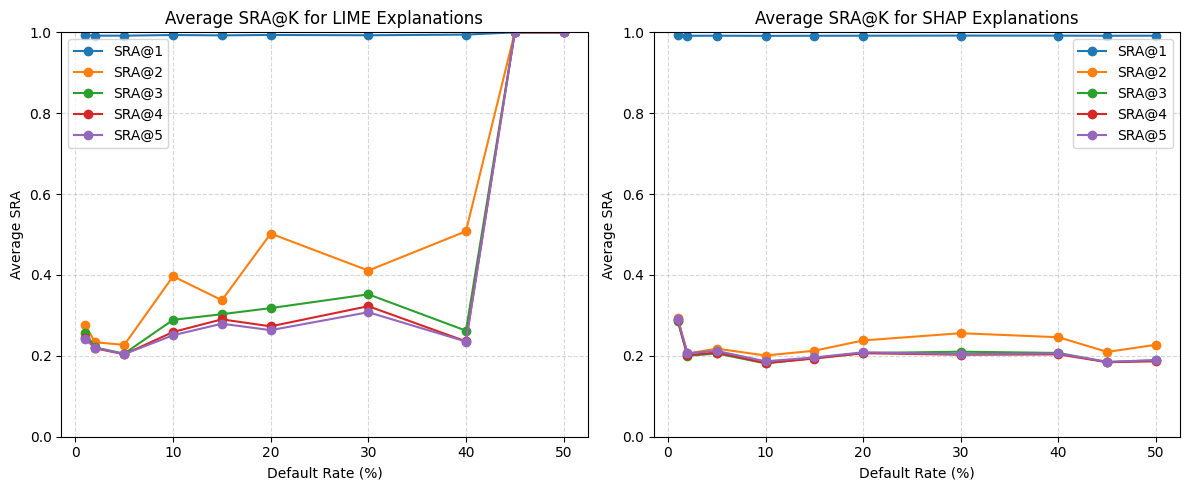

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ratios = [1, 2, 5, 10, 15, 20, 30, 40, 45, 50]

# how many runs per pseudo-target
RUNS_PER_TARGET = 10


# =========================
# Rank computation
# =========================
def get_rank_matrix(df):
    n_runs, n_features = df.shape
    rank_mat = np.zeros((n_runs, n_features), dtype=int)

    for i in range(n_runs):
        vals = df.iloc[i].values
        sorted_idx = np.argsort(-vals)
        ranks = np.empty(n_features, dtype=int)
        ranks[sorted_idx] = np.arange(1, n_features + 1)
        rank_mat[i] = ranks

    return rank_mat


# =========================
# TRUE SRA (normalized)
# =========================
def compute_true_sra(rank_mat, K):
    n_runs, n_features = rank_mat.shape

    S = set(np.where(rank_mat <= K)[1])
    if len(S) == 0:
        return np.nan

    S = list(S)
    ranks_S = rank_mat[:, S]

    avg_rank = ranks_S.mean(axis=0)

    dev2 = ((ranks_S - avg_rank) ** 2).sum()
    observed = np.sqrt(dev2 / (n_runs * len(S)))

    worst_var = (n_features**2 - 1) / 12
    max_dev = np.sqrt(worst_var)

    sra = 1 - (observed / (max_dev + 1e-8))

    return np.clip(sra, 0, 1)


# =========================
# MAIN
# =========================
results = {
    'SHAP': {K: [] for K in range(1, 6)},
    'LIME': {K: [] for K in range(1, 6)}
}

for ratio in ratios:

    shap_df = pd.read_csv(f'results/iterations/shap_iterations_{ratio}.csv')
    lime_df = pd.read_csv(f'results/iterations/lime_iterations_{ratio}.csv')

    # remove non-feature columns if any
    shap_df = shap_df.select_dtypes(include=[np.number])
    lime_df = lime_df.select_dtypes(include=[np.number])

    n_runs = len(shap_df)
    n_targets = n_runs // RUNS_PER_TARGET

    shap_sra_all = {K: [] for K in range(1, 6)}
    lime_sra_all = {K: [] for K in range(1, 6)}

    for t in range(n_targets):

        start = t * RUNS_PER_TARGET
        end = start + RUNS_PER_TARGET

        shap_sub = shap_df.iloc[start:end]
        lime_sub = lime_df.iloc[start:end]

        shap_ranks = get_rank_matrix(shap_sub)
        lime_ranks = get_rank_matrix(lime_sub)

        for K in range(1, 6):
            shap_sra_all[K].append(compute_true_sra(shap_ranks, K))
            lime_sra_all[K].append(compute_true_sra(lime_ranks, K))

    # average across pseudo-targets
    for K in range(1, 6):
        results['SHAP'][K].append(np.nanmean(shap_sra_all[K]))
        results['LIME'][K].append(np.nanmean(lime_sra_all[K]))


# =========================
# PLOT (paper style)
# =========================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for method, ax in zip(['LIME', 'SHAP'], axs):
    for K in range(1, 6):
        ax.plot(ratios, results[method][K], marker='o', label=f'SRA@{K}')

    ax.set_xlabel('Default Rate (%)')
    ax.set_ylabel('Average SRA')
    ax.set_title(f'Average SRA@K for {method} Explanations')

    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

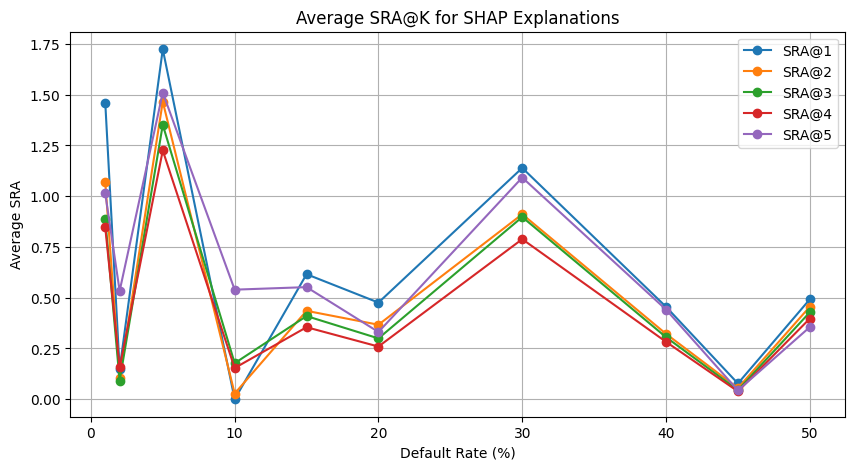

In [21]:
import pandas as pd
import numpy as np
import os
from scipy.stats import rankdata
import matplotlib.pyplot as plt

# === CONFIG ===
ratios = ["1", "2", "5", "10", "15", "20", "30", "40", "45", "50"]
top_k_values = [1, 2, 3, 4, 5]
method = "shap"  # or "lime"
iteration_dir = "results/iterations"

# === SRA calculation ===
def compute_sra(true_ranks_list, k):
    sra_values = []
    for i in range(len(true_ranks_list)):
        for j in range(i + 1, len(true_ranks_list)):
            ranks_i = true_ranks_list[i][:k]
            ranks_j = true_ranks_list[j][:k]
            sra = np.sqrt(np.mean([(r_i - r_j) ** 2 for r_i, r_j in zip(ranks_i, ranks_j)]))
            sra_values.append(sra)
    return np.mean(sra_values)

# === Main Loop ===
sra_k_by_ratio = {k: [] for k in top_k_values}

for ratio in ratios:
    df = pd.read_csv(f"{iteration_dir}/{method}_iterations_{ratio}.csv")
    feature_names = df.columns[:-1]  # exclude 'iteration'
    grouped = df.groupby("iteration")
    ranks_by_iter = []

    for _, group in grouped:
        avg_importances = group[feature_names].abs().mean().values
        rank = rankdata(-avg_importances, method="ordinal")  # higher importance → lower rank number
        ranks_by_iter.append(rank)

    for k in top_k_values:
        sra = compute_sra(ranks_by_iter, k)
        sra_k_by_ratio[k].append(sra)

# === Plot ===
plt.figure(figsize=(10, 5))
for k in top_k_values:
    plt.plot([int(r) for r in ratios], sra_k_by_ratio[k], marker='o', label=f"SRA@{k}")
plt.title(f"Average SRA@K for {method.upper()} Explanations")
plt.xlabel("Default Rate (%)")
plt.ylabel("Average SRA")
plt.legend()
plt.grid(True)
plt.show()

SHAP ratio 1%
SHAP ratio 2%
SHAP ratio 5%
SHAP ratio 10%
SHAP ratio 15%
SHAP ratio 20%
SHAP ratio 30%
SHAP ratio 40%
SHAP ratio 45%
SHAP ratio 50%
LIME ratio 1%
LIME ratio 2%
LIME ratio 5%
LIME ratio 10%
LIME ratio 15%
LIME ratio 20%
LIME ratio 30%
LIME ratio 40%
LIME ratio 45%
LIME ratio 50%


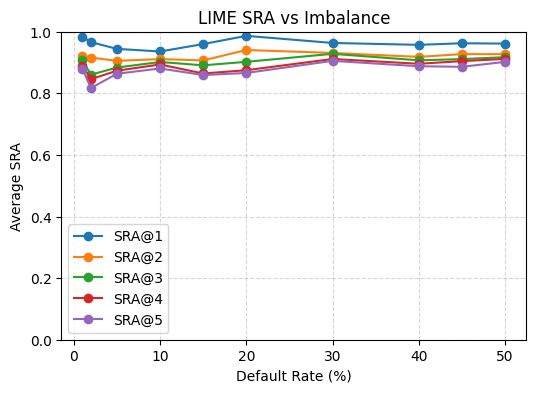

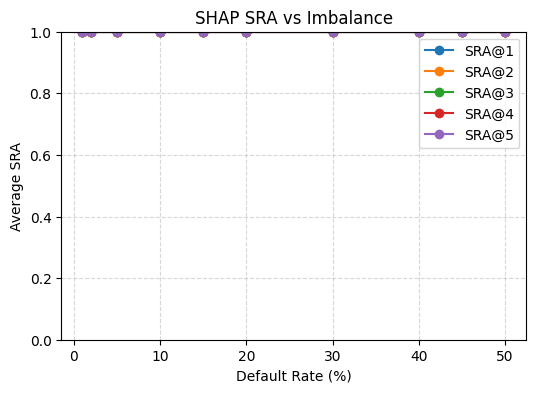

In [24]:
 import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
ratios = [1, 2, 5, 10, 15, 20, 30, 40, 45, 50]
DATA_PATH = "results/fixed"

# =========================
# RANK MATRIX
# =========================
def get_rank_matrix(df):
    df = df.astype(float)

    n_runs, n_features = df.shape
    rank_mat = np.zeros((n_runs, n_features), dtype=int)

    for i in range(n_runs):
        vals = df.iloc[i].values
        sorted_idx = np.argsort(-vals)
        ranks = np.empty(n_features, dtype=int)
        ranks[sorted_idx] = np.arange(1, n_features + 1)
        rank_mat[i] = ranks

    return rank_mat


# =========================
# NORMALIZED SRA (PAPER)
# =========================
def compute_sra(rank_mat, K):
    n_runs, n_features = rank_mat.shape

    S = set(np.where(rank_mat <= K)[1])
    if len(S) == 0:
        return np.nan

    S = list(S)
    ranks_S = rank_mat[:, S]

    avg_rank = ranks_S.mean(axis=0)

    # observed deviation
    dev2 = ((ranks_S - avg_rank) ** 2).sum()
    observed = np.sqrt(dev2 / (n_runs * len(S)))

    # maximum possible deviation (uniform ranking)
    worst_var = (n_features**2 - 1) / 12
    max_dev = np.sqrt(worst_var)

    # 🔴 NORMALIZED SRA (IMPORTANT)
    sra = 1 - (observed / (max_dev + 1e-8))

    return np.clip(sra, 0, 1)


# =========================
# COMPUTE METHOD
# =========================
def compute_method(method):

    results = {K: [] for K in range(1, 6)}

    for ratio in ratios:

        print(f"{method.upper()} ratio {ratio}%")

        df = pd.read_csv(f"{DATA_PATH}/{method}_{ratio}.csv")

        targets = df['target_id'].unique()

        for K in range(1, 6):

            sra_vals = []

            for t in targets:

                sub = df[df['target_id'] == t].drop(columns=['target_id', 'run_id'])

                # ensure numeric
                sub = sub.apply(pd.to_numeric, errors='coerce').fillna(0)

                rank_mat = get_rank_matrix(sub)

                sra_vals.append(compute_sra(rank_mat, K))

            results[K].append(np.mean(sra_vals))

    return results


# =========================
# RUN
# =========================
shap_results = compute_method("shap")
lime_results = compute_method("lime")


# =========================
# PLOT (PAPER STYLE)
# =========================
def plot_results(results, title):

    plt.figure(figsize=(6,4))

    for K in range(1, 6):
        plt.plot(ratios, results[K], marker='o', label=f'SRA@{K}')

    plt.xlabel("Default Rate (%)")
    plt.ylabel("Average SRA")
    plt.title(title)

    # 🔴 paper-style
    plt.ylim(0, 1)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.show()


# separate plots (like paper)
plot_results(lime_results, "LIME SRA vs Imbalance")
plot_results(shap_results, "SHAP SRA vs Imbalance")